In [1]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import cutouts_to_patches.cutouts_to_patches as cutouts_to_patches

In [2]:
import visualization.visualization as vis

In [3]:
from nemi import NEMI, SingleNemi

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
import torch
import numpy as np

import colorsys
from einops import rearrange
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

import itertools

In [5]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="1_00",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [6]:
# cutouts_dataloader = cutouts_dataset.get_cutout_loader(source=source, subset=True, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=1, batch_size=64)
data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']

cutouts_dataloader = cutouts_dataset.get_cutout_loader(data_channels=data_channels, source=source, subset=False, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=4, batch_size=64)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43959 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:40825' processes=4 threads=32, memory=128.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/43959/status
dropped 0 cutouts with sea ice
dropped 0 cutouts with NaN
kept 3250 / 3250 cutouts
Channels : ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'gradb2', 'oceTAUX', 'oceTAUY', 'gradrho2', 'turner_angle', 'strain_n', 'strain_s', 'strain_mag', 'divergence', 'relative_vorticity', 'coriolis_f', 'oceQnet', 'ekman_pumping', 'wind_stress_curl', 'XC', 'YC']


In [7]:
len(cutouts_dataloader) * 64 

3264

In [8]:
import math 

patch_size = 8
patched_loader = cutouts_to_patches.PatchedDataLoader(cutouts_dataloader, patch_size=patch_size)
print(len(patched_loader))

patches = torch.cat(
    [patches.reshape(patches.shape[0] * patches.shape[1], -1) for patches in patched_loader], dim=0
).numpy()

print(patches.shape)
print(math.log(patches.shape[0])+15)

51
(208000, 1408)
27.245293358683455


In [9]:
EMBEDDING_DIMENSIONS = 3

In [10]:
# Run NEMI on the patches (GPU: cuML UMAP + clustering)
nemi = NEMI(params={
    "device": "gpu",
    "embedding_dict":  {"n_components": EMBEDDING_DIMENSIONS, "n_neighbors": 150, "min_dist": 0.0},
    "clustering_dict": {"method": "hdbscan", "min_cluster_size": 1000, "min_samples": 500},
})

# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": 2, "n_neighbors": 150, "min_dist": 0.0},
#     "clustering_dict": {"method": "agglomerative", "n_clusters": 500, "linkage": "single", "n_neighbors": 30},
# })


In [11]:
# single member to start; bump n (with assess_overlap=True) for the ensemble
nemi.run(patches, n=5, output="nemi_out.npz", assess_overlap=True)

labels    = nemi.clusters      # (N,) cluster label per patch
embedding = nemi.embedding     # (N, 3) UMAP embedding
print("labels", labels.shape, "| embedding", embedding.shape)



  0%|          | 0/5 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-22 14:51:52.518] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-22 14:51:52.519] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree.                 setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-22 14:52:00.204] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 1000, 'min_samples': 500}


 20%|██        | 1/5 [00:21<01:26, 21.55s/it]

Clusters found: 26
Sorting clusters
Fitting the embedding
[2026-07-22 14:52:11.619] [CUML] [info] Building knn graph using nn descent
[2026-07-22 14:52:11.623] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-22 14:52:11.623] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree.                 setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-22 14:52:19.253] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 1000, 'min_samples': 500}


 40%|████      | 2/5 [00:39<00:59, 19.72s/it]

...

Clusters found: 35
Sorting clusters
Fitting the embedding
[2026-07-22 14:53:06.257] [CUML] [info] Building knn graph using nn descent
[2026-07-22 14:53:06.259] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-22 14:53:06.259] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree.                 setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-22 14:53:13.958] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 1000, 'min_samples': 500}


100%|██████████| 5/5 [01:35<00:00, 19.01s/it]

Clusters found: 37
Sorting clusters


37 37
labels (208000,) | embedding (208000, 3)


/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/nemi/workflow.py:485: RuntimeWarning: divide by zero encountered in log
  H = -(p * np.where(p > 0, np.log(p), 0.0)).sum(axis=0) # (N,) nats


In [15]:
d = np.load("nemi_out.npz")
print(d.files) 

member_clusters = d["member_clusters"]  # (n, N)  per-member labels  <- entropy input
embeddings      = d["embeddings"]       # (n, N, d) per-member UMAP embeddings
clusters        = d["clusters"]         # (N,)   consensus labels (assess_overlap ran)
embedding       = d["embedding"]        # (N, d) consensus/base embedding
entropy         = d["entropy"]
unassigned      = d["unassigned_frac"]

print(embeddings.shape)
print(member_clusters.shape)
print(clusters.shape)
print(embedding.shape)
print(entropy.shape)
print(unassigned.shape)

['embeddings', 'member_clusters', 'clusters', 'embedding', 'entropy', 'unassigned_frac']
(5, 208000, 3)
(5, 208000)
(208000,)
(208000, 3)
(208000,)
(208000,)


In [18]:
def distinct_cmap(n):
    """Qualitative colormap with n visually distinct colors (tab20-style, any n)."""
    colors = []
    for i in range(n):
        h = (i * 0.61803398875) % 1.0        # golden-ratio hue spacing
        s = 0.55 + 0.35 * (i % 2)            # two saturation tiers
        v = 0.75 + 0.20 * ((i // 2) % 2)     # two value tiers
        colors.append(colorsys.hsv_to_rgb(h, s, v))
    return ListedColormap(colors)

disc_cmap = distinct_cmap(len(clusters))

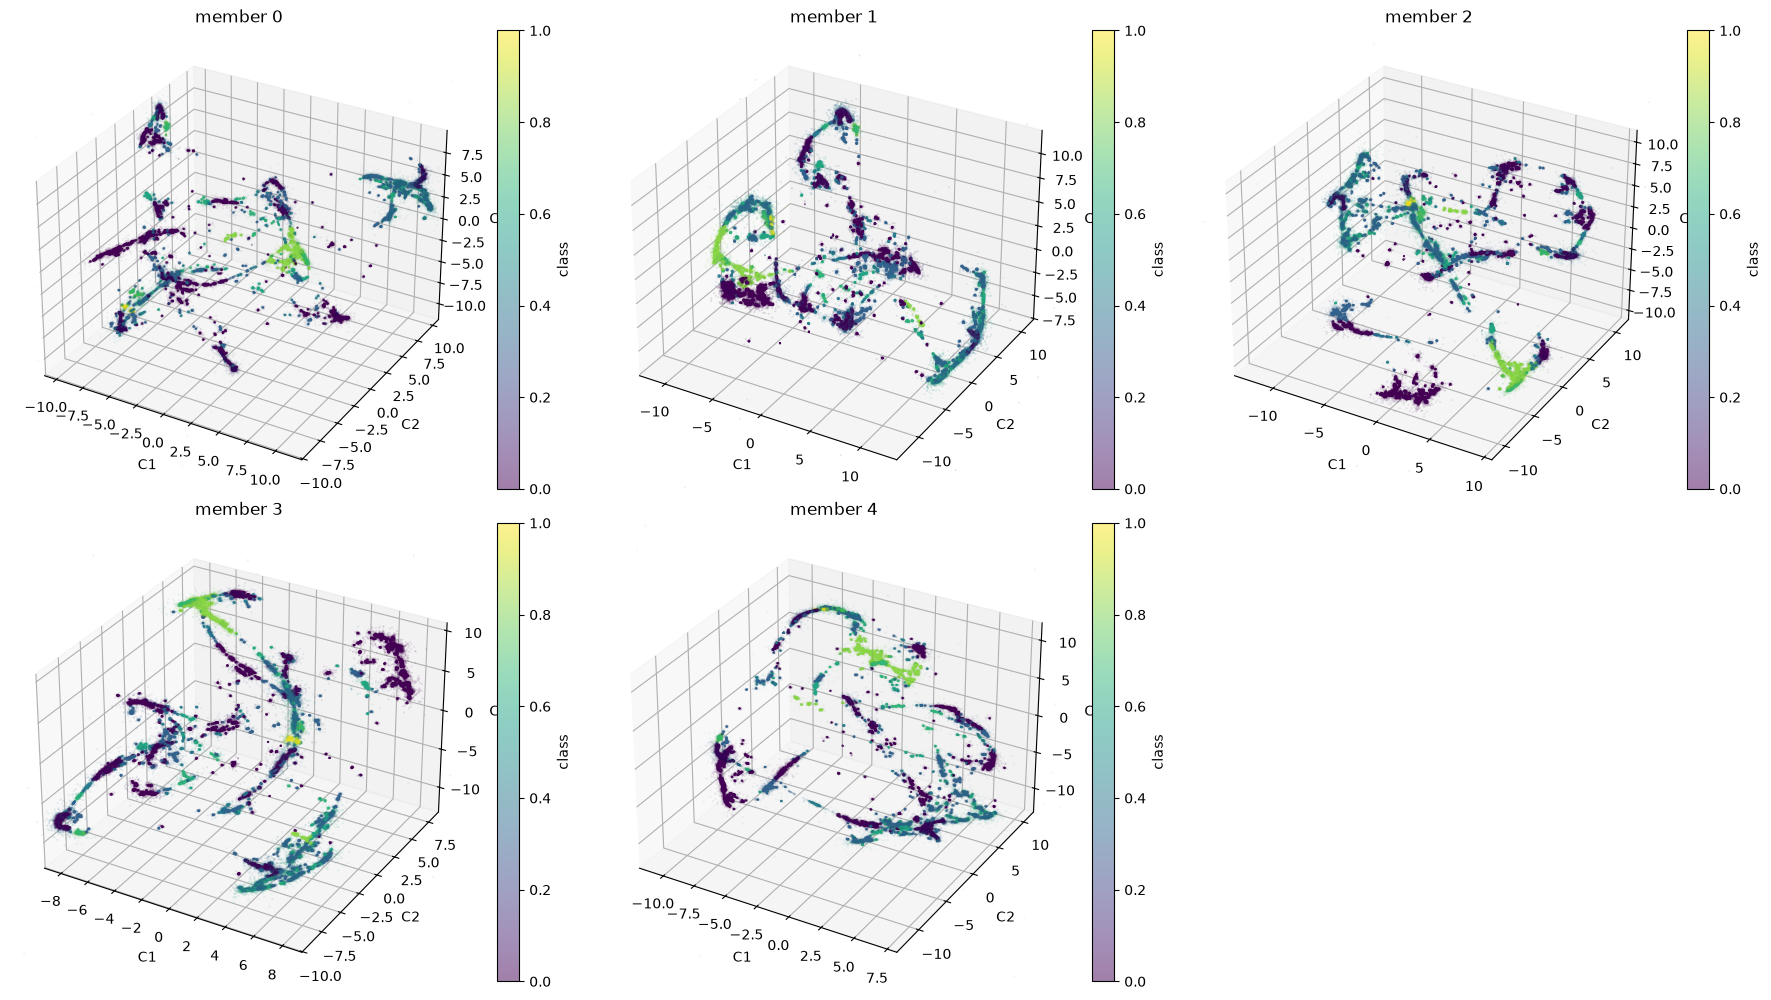

In [19]:
# vis.vis_dim_redux(embeddings[1], labels=entropy, dims=2, alpha=0.5, categorical=False, cmap="viridis")

vis.vis_dim_redux_list(d["embeddings"], labels=entropy, dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

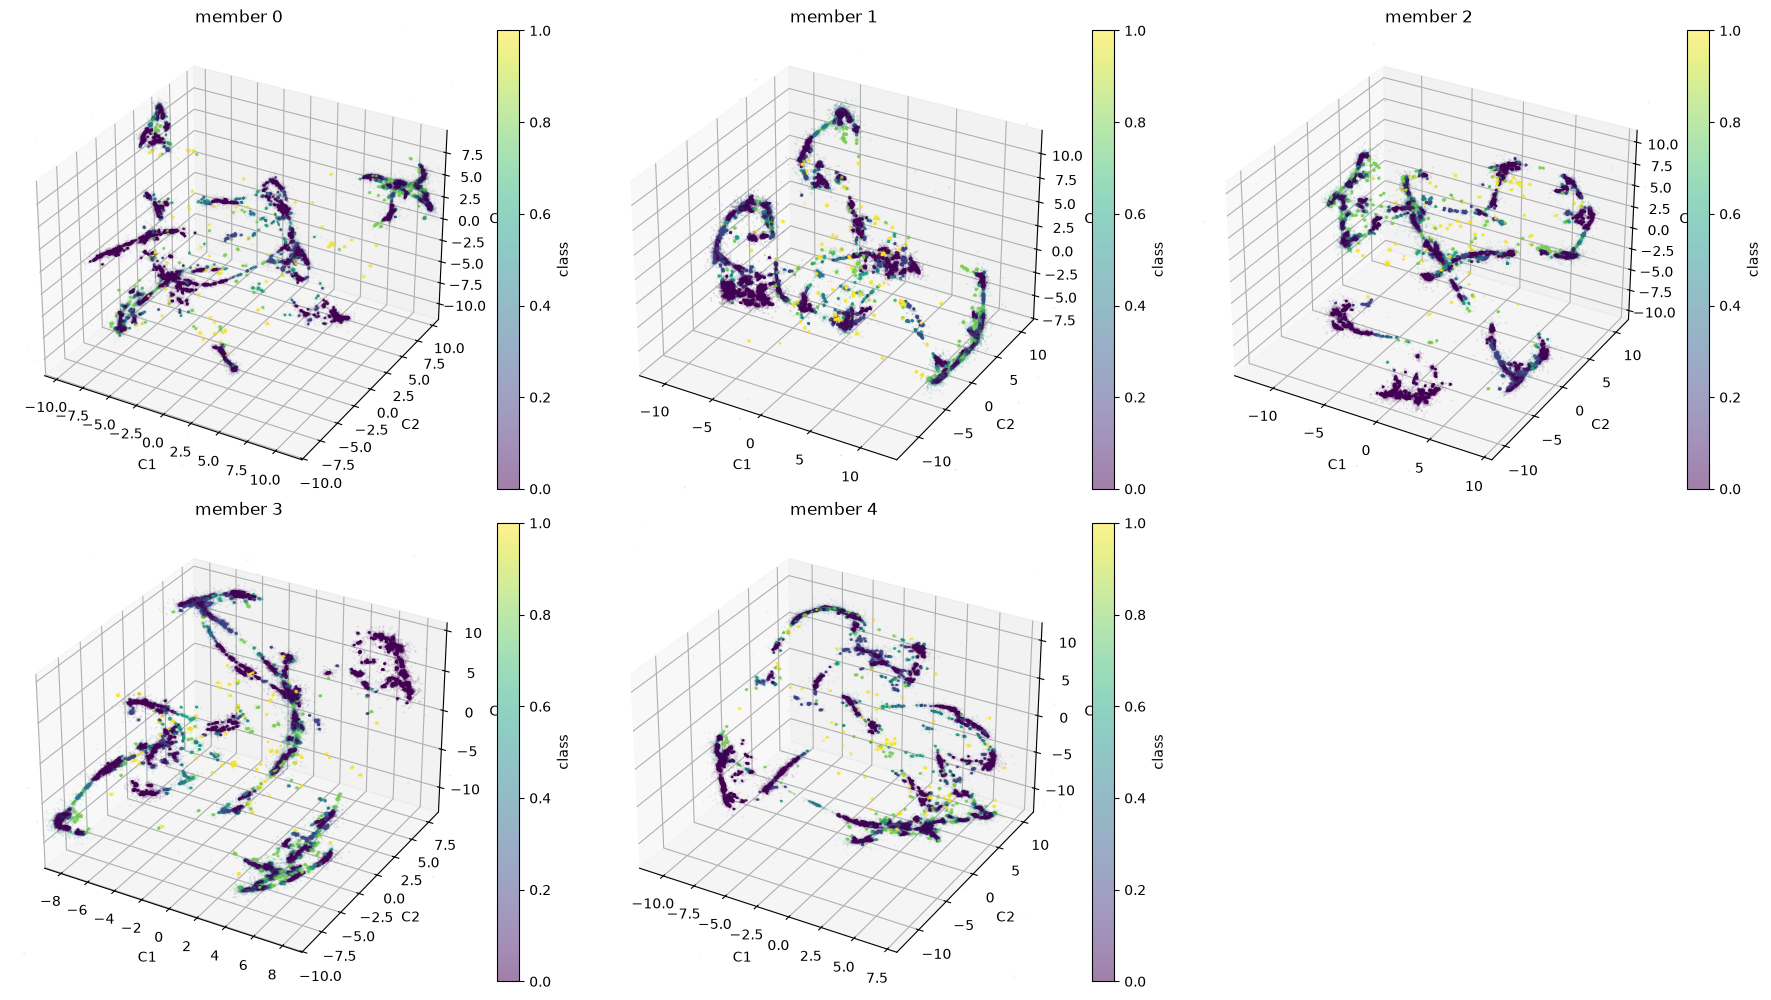

In [24]:
vis.vis_dim_redux_list(d["embeddings"], labels=unassigned, dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

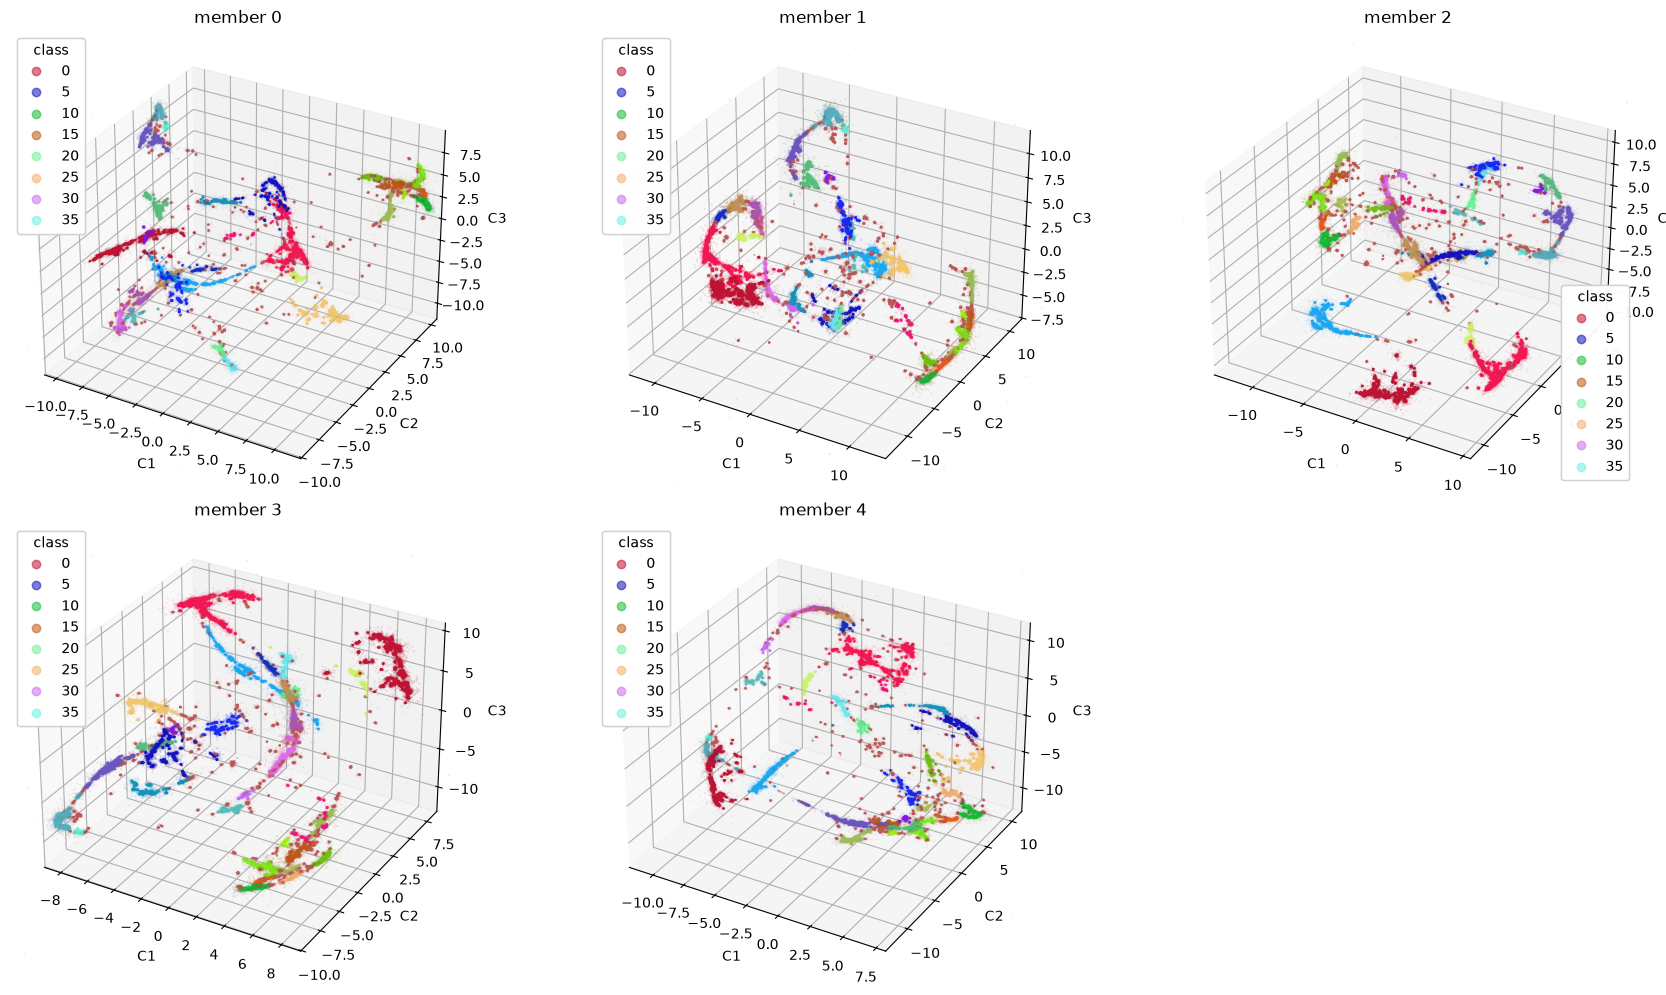

In [20]:
#labeled by consensus cluster
vis.vis_dim_redux_list(d["embeddings"], labels=clusters, dims=EMBEDDING_DIMENSIONS, titles=[f"member {i}" for i in range(len(d["embeddings"]))], cmap=disc_cmap, alpha=0.5)

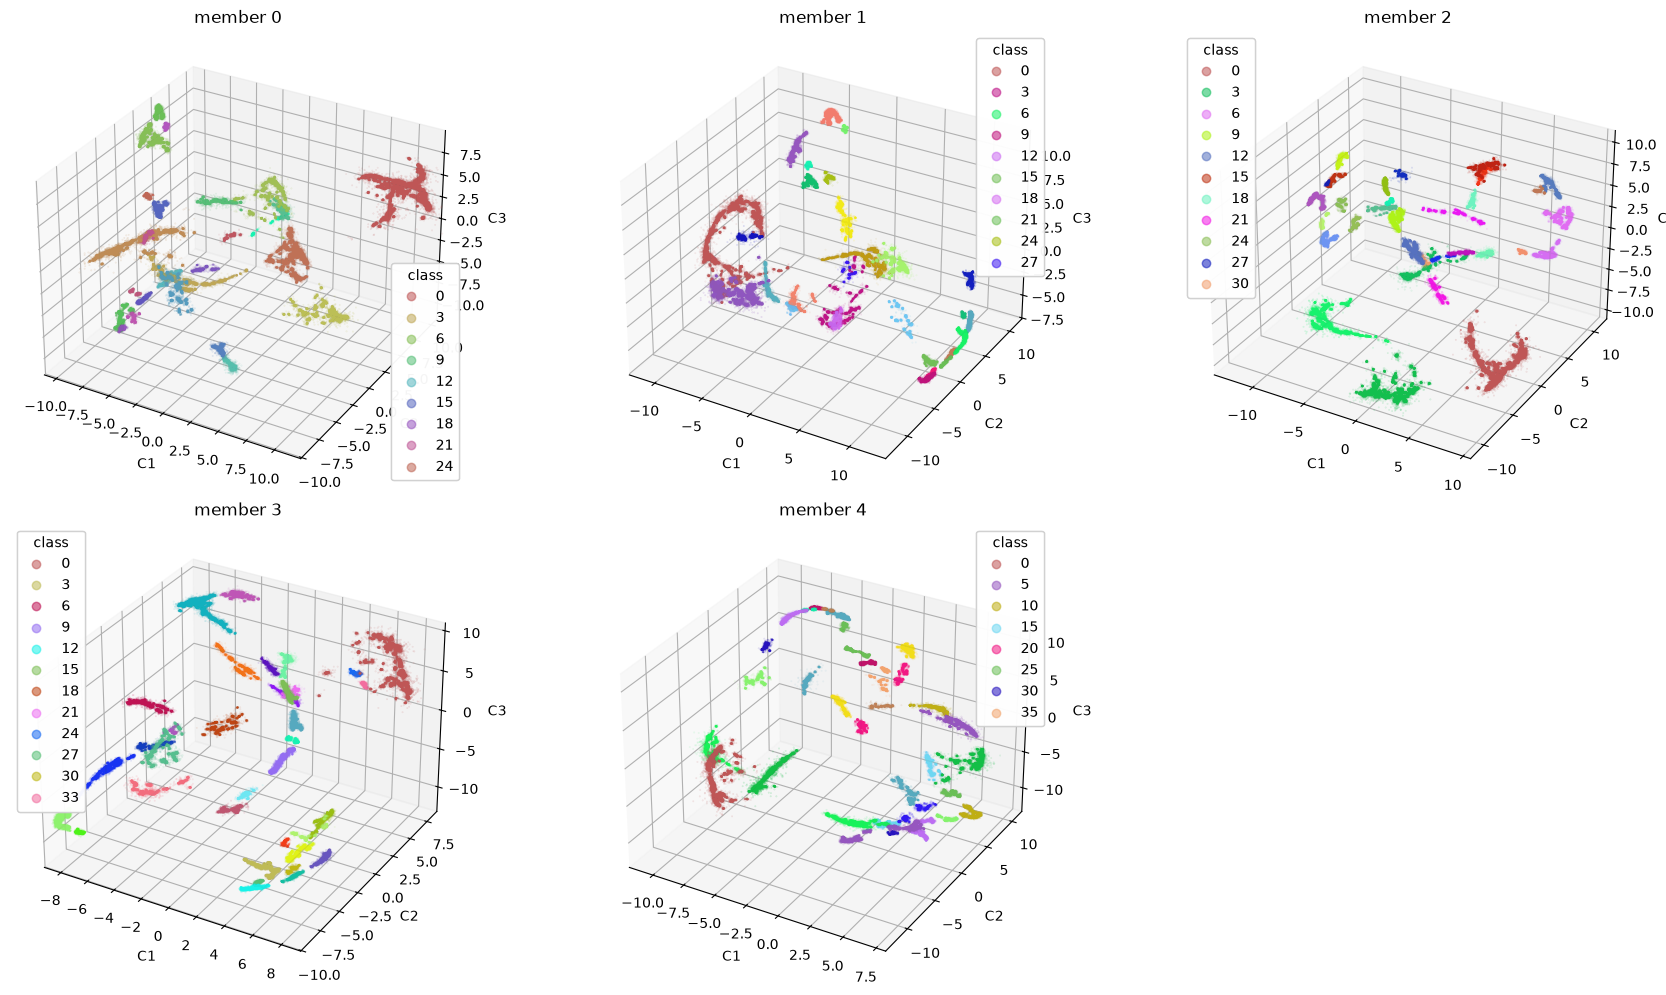

In [21]:
# colored by embedding's clustering
vis.vis_dim_redux_list(d["embeddings"], labels=d["member_clusters"], dims=EMBEDDING_DIMENSIONS,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], cmap=disc_cmap)

In [22]:
np.unique(clusters)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35,
       36])

torch.Size([64, 64, 22, 8, 8])
torch.Size([64, 22, 64, 64])


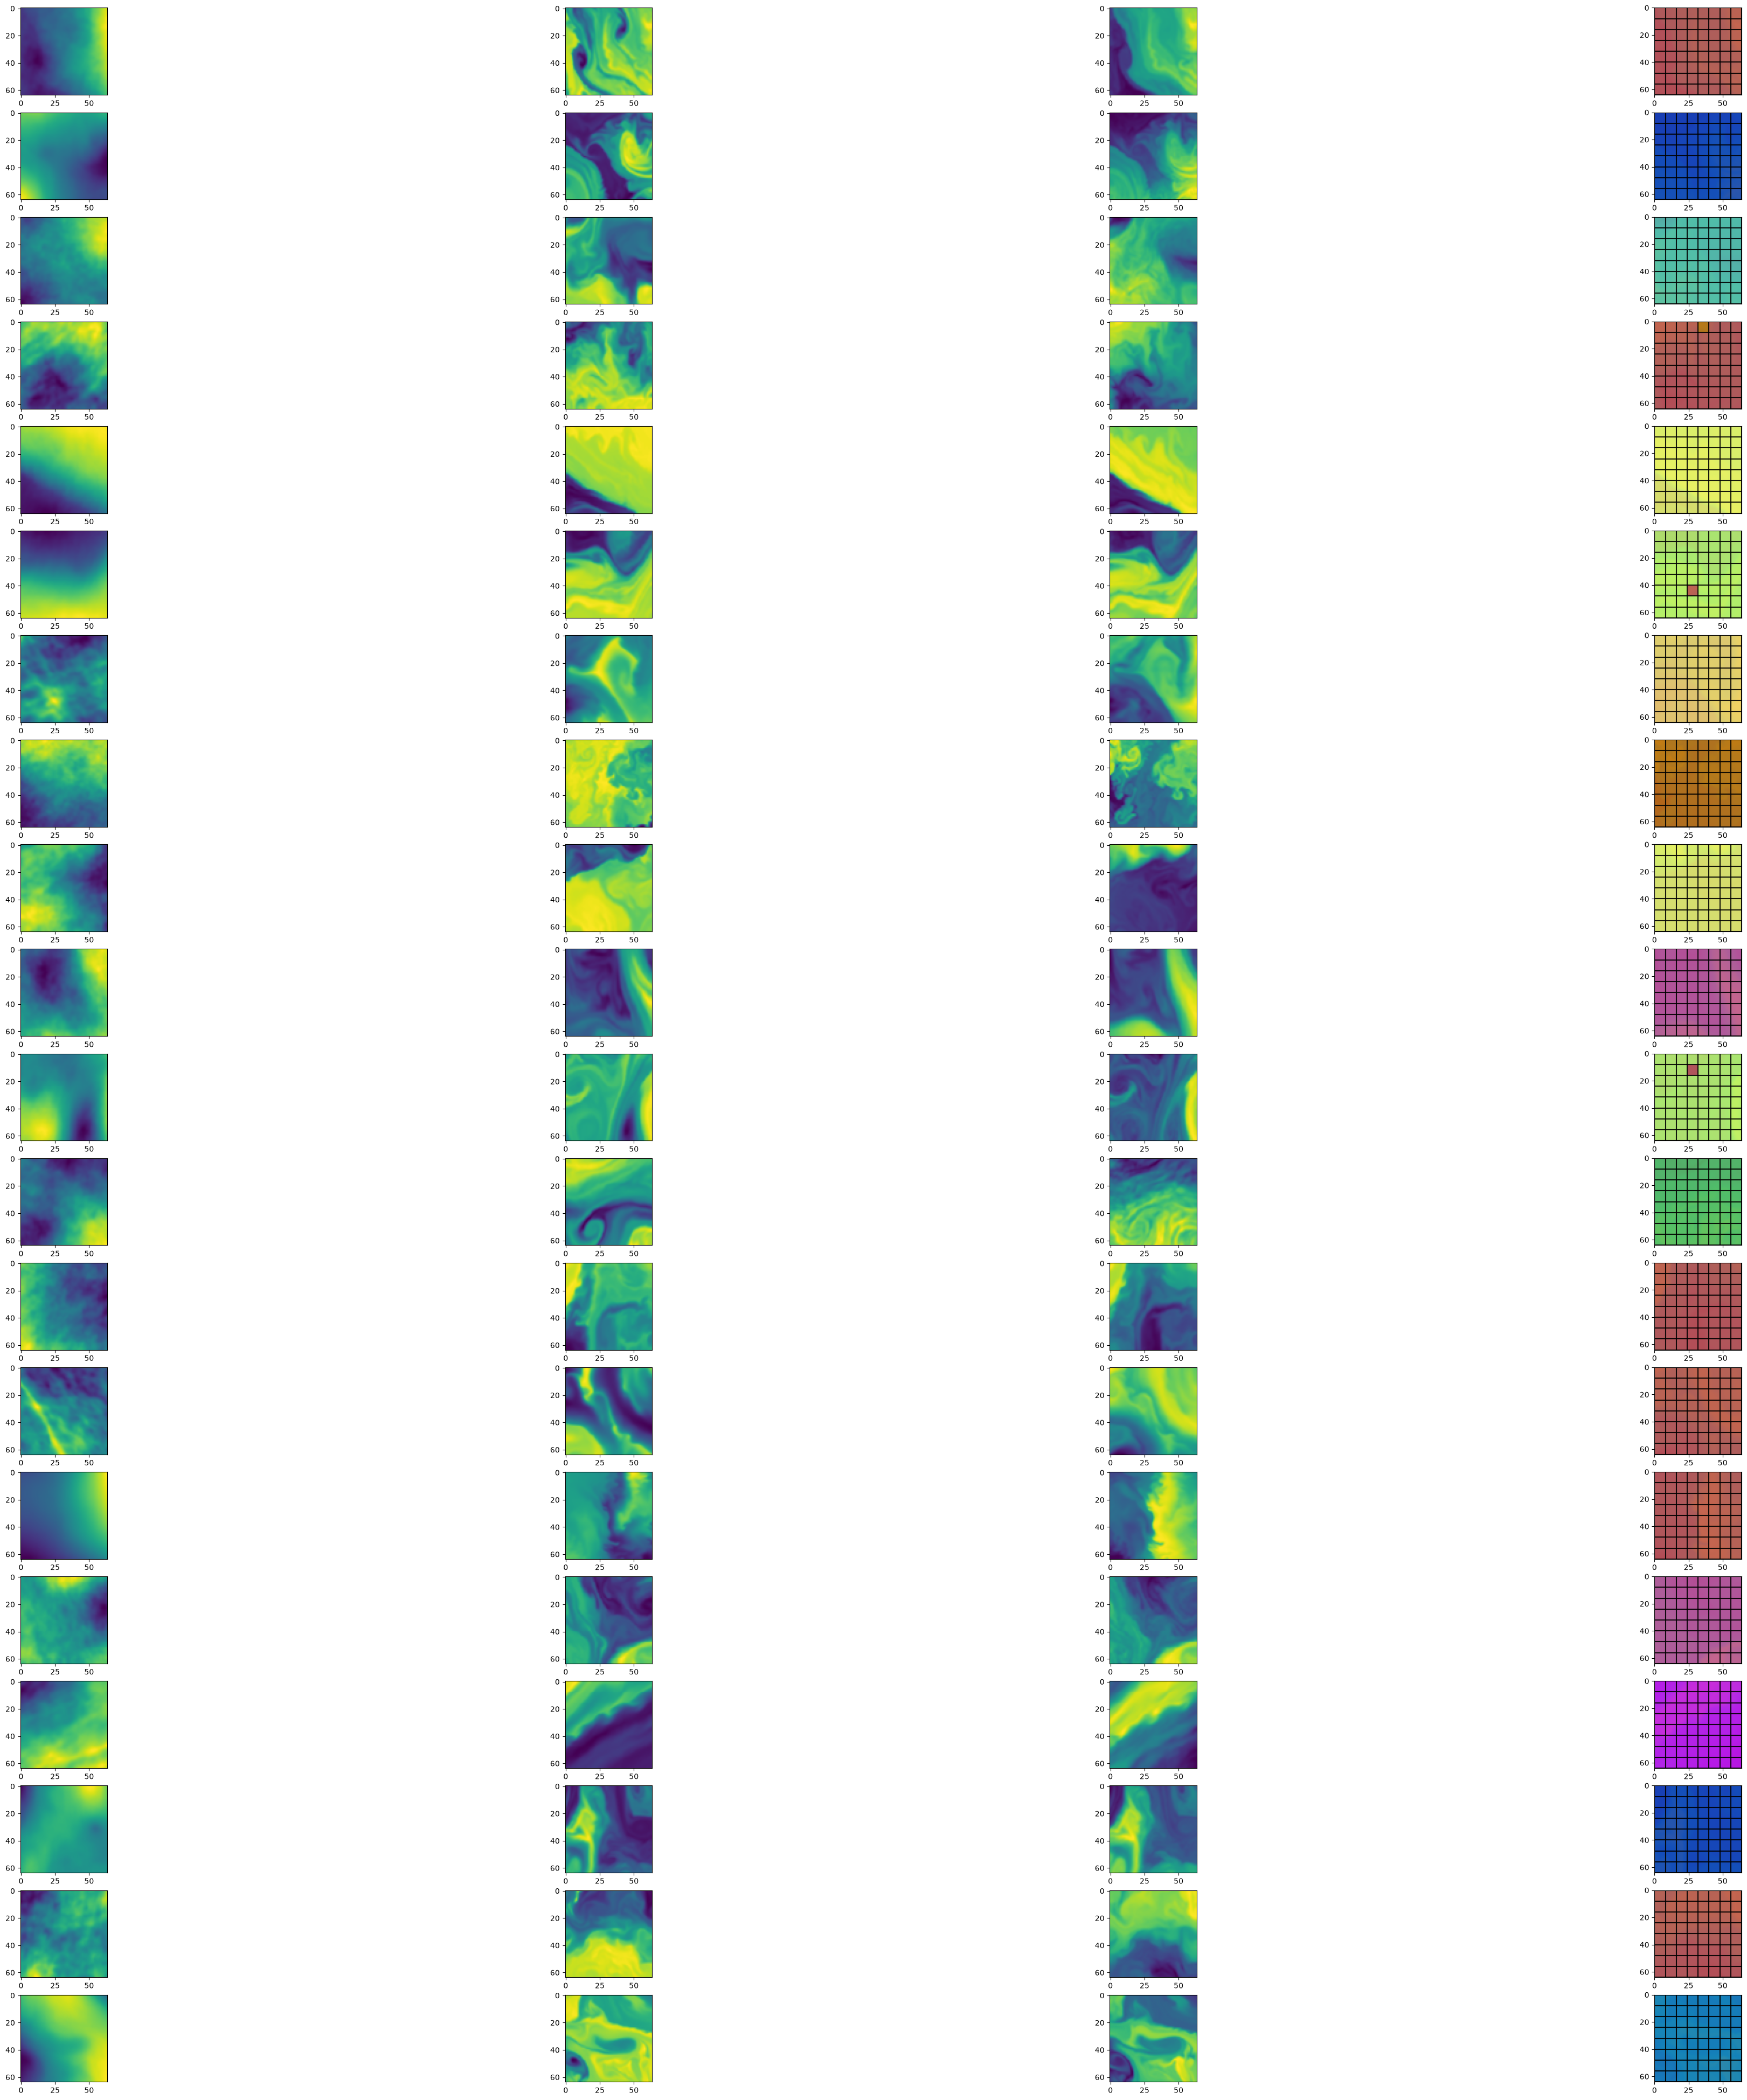

In [23]:
# Patches to Image
def make_image_from_patches(cutouts_dataloader, patched_loader, labels, batch_index=0,
                            batch_size=64, patch_size=8, bg_channel=2, number_rows=6):
    # Requires the loaders to be non-shuffled and deterministic so that `labels`
    # (flat, in loader order) line up with the re-iterated patches.
    batch_imgs = next(itertools.islice(iter(cutouts_dataloader), batch_index, None))
    batch_patches = next(itertools.islice(iter(patched_loader), batch_index, None))

    print(batch_patches.shape)
    print(batch_imgs.shape)

    imgs_in_batch, patches_per_image = batch_patches.shape[0], batch_patches.shape[1]
    number_rows = min(number_rows, imgs_in_batch)

    # One discrete colour per cluster id, shared across all panels.
    n_clusters = int(labels.max()) + 1
    disc_cmap = distinct_cmap(n_clusters)
    norm = BoundaryNorm(np.arange(n_clusters + 1) - 0.5, n_clusters)

    fig, axes = plt.subplots(number_rows, 4, figsize=(50, 50))
    for i in range(number_rows):
        img = batch_imgs[i]
        for c in range(3):
            axes[i, c].imshow(img[c])

        H, W = img.shape[1], img.shape[2]
        n_patches_h, n_patches_w = H // patch_size, W // patch_size

        # reconstruct one channel from its patches as the overlay background
        patches = batch_patches[i]
        bg = rearrange(patches[:, bg_channel], '(h w) p1 p2 -> (h p1) (w p2)',
                       h=n_patches_h, w=n_patches_w)
        axes[i, 3].imshow(bg, extent=[0, W, H, 0])

        # labels are flat in loader order: preceding (full) batches, then earlier
        # images in this batch.
        start = batch_index * batch_size * patches_per_image + i * patches_per_image
        patch_labels = np.asarray(labels[start:start + patches_per_image])
        assert patch_labels.size == n_patches_h * n_patches_w, \
            f"expected {n_patches_h * n_patches_w} labels, got {patch_labels.size}"
        label_grid = patch_labels.reshape(n_patches_h, n_patches_w)

        axes[i, 3].imshow(label_grid, cmap=disc_cmap, norm=norm, alpha=0.9,
                          extent=[0, W, H, 0], interpolation='nearest')

        for g in range(0, H + 1, patch_size):
            axes[i, 3].axhline(g, color='black', linewidth=1.5, alpha=0.9)
        for g in range(0, W + 1, patch_size):
            axes[i, 3].axvline(g, color='black', linewidth=1.5, alpha=0.9)


make_image_from_patches(cutouts_dataloader, patched_loader,clusters, batch_index=0, batch_size=64, number_rows=20)